In [ ]:
import pickle
import pandas as pd
import os
import sys
sys.path.append(os.path.abspath('..'))
from utils.SemrepOutputLoader import SemrepOutputLoader
from tqdm import tqdm
import pandas as pd
import random
from utils.TermEmbedder import TermEmbedder
from HGCR_util.lazy_json_kv_loader import LazyJsonlAbstractLoader
from HGCR_util import text_util
from HGCR_util.emb_lookup.abstr_emb_lookup import MedlineNumpyEmbeddings
from pathlib import Path
from collections import defaultdict
import numpy as np
random.seed(42)

In [16]:
terms_set_path = 'seen_terms.pkl'

with open(terms_set_path, 'rb') as file:
    seen_terms = pickle.load(file)

print(len(seen_terms))

836627


In [3]:
pmids_path = 'training_pmids.txt'

with open(pmids_path, 'r') as file:
    training_pmids = set(line.strip() for line in file)

print(len(training_pmids))

523561


In [4]:
folder_path = '60k_pmid_dataset_chunks_sentencewise_negatives'
pkl_files = [f for f in os.listdir(folder_path) if f.endswith('.pkl')]
len(pkl_files)

115

In [14]:
with open('embed_dict.pkl', 'rb') as f:
    term_embeds = pickle.load(f)

In [ ]:
def build_eval_dataset(
    folder_path,
    training_pmids,
    term_embeds,
    seen_terms,
    use_semantic_types=True,
    target_pos=50000,
    target_neg=95000
):
    seen_dataset = []
    unseen_dataset = []

    max_per_dataset = target_pos + target_neg

    for fname in tqdm(os.listdir(folder_path)):
        if not fname.endswith('.pkl'):
            continue

        df = pd.read_pickle(os.path.join(folder_path, fname))

        for _, row in df.iterrows():
            pmid = str(row['pmid'])
            if pmid in training_pmids:
                continue

            abstract_emb = row['abstract_emb']
            terms_per_sentence = row['terms_one_hot']
            rels_per_sentence = row['relations']
            negs_per_sentence = row['negatives']

            for sent_idx in range(len(terms_per_sentence)):
                sent_terms = terms_per_sentence[sent_idx]
                rels = rels_per_sentence[sent_idx]
                negs = negs_per_sentence[sent_idx]

                term_lookup = {t: np.array(onehot, dtype=np.float32) for t, onehot in sent_terms}

                if len(rels) == 0:
                    continue

                pos_pair = random.choice(rels)
                t1, t2 = pos_pair
                if t1 not in term_lookup or t2 not in term_lookup:
                    continue
                if t1 not in term_embeds or t2 not in term_embeds:
                    continue

                parts = [
                    np.array(abstract_emb, dtype=np.float32),
                    term_embeds[t1],
                    term_embeds[t2],
                ]
                if use_semantic_types:
                    parts.extend([term_lookup[t1], term_lookup[t2]])

                input_vec = np.concatenate(parts)
                is_seen = t1 in seen_terms and t2 in seen_terms
                pos_sentry = {
                    'pmid': pmid,
                    'sentence_idx': sent_idx,
                    'pair': (t1, t2),
                    'label': 1,
                    'embedding': input_vec
                }

                neg_candidates = [
                    pair for pair in negs
                    if all(term in term_lookup and term in term_embeds term in pair)
                ]

                random.shuffle(neg_candidates)
                neg_entries = []
                for t1n, t2n in neg_candidates[:20]:
                    parts = [
                        np.array(abstract_emb, dtype=np.float32),
                        term_embeds[t1n],
                        term_embeds[t2n],
                    ]
                    if use_semantic_types:
                        parts.extend([term_lookup[t1n], term_lookup[t2n]])

                    neg_input = np.concatenate(parts)
                    neg_entries.append({
                        'pmid': pmid,
                        'sentence_idx': sent_idx,
                        'pair': (t1n, t2n),
                        'label': 0,
                        'embedding': neg_input
                    })
                if len(neg_entries) < 5:
                    continue

                if is_seen and len(seen_dataset) < max_per_dataset:
                    seen_dataset.append(pos_entry)
                    seen_dataset.extend(neg_entries[:min(20, len(neg_entries))])
                elif not is_seen and len(unseen_dataset) < max_per_dataset:
                    unseen_dataset.append(pos_entry)
                    unseen_dataset.extend(neg_entries[:min(20, len(neg_entries))])

            if len(seen_dataset) >= max_per_dataset and len(unseen_dataset) >= max_per_dataset:
                break
        if len(seen_dataset) >= max_per_dataset and len(unseen_dataset) >= max_per_dataset:
            break
    return seen_dataset, unseen_dataset
            

In [33]:
seen_dataset = []
unseen_dataset = []

target_pairs = 1000000

for fname in tqdm(os.listdir(folder_path)):
    if not fname.endswith('.pkl'):
        continue

    df = pd.read_pickle(os.path.join(folder_path, fname))

    for _, row in df.iterrows():
        pmid = str(row['pmid'])

        if pmid in training_pmids:
            continue

        abstract_emb = row['abstract_embeddings']
        terms_per_sentence = row['terms_one_hot']
        rels_per_sentence = row['relations']
        negs_per_sentence = row['negatives']

        for i in range(len(terms_per_sentence)):
            sentence_terms = terms_per_sentence[i]
            term_lookup = {t: np.array(onehot, dtype=np.float32) for t, onehot in sentence_terms}
            rels = rels_per_sentence[i]
            negs = negs_per_sentence[i]

            for pair_list, label in [(rels, 1), (negs, 0)]:
                for t1, t2 in pair_list:
                    if t1 not in term_lookup or t2 not in term_lookup:
                        continue
                    if t1 not in term_embeds or t2 not in term_embeds:
                        continue

                    t1_onehot = term_lookup[t1]
                    t2_onehot = term_lookup[t2]
                    t1_emb = term_embeds[t1]
                    t2_emb = term_embeds[t2]

                    combined = np.concatenate([
                        abstract_emb,
                        t1_emb,
                        t2_emb,
                        t1_onehot,
                        t2_onehot
                    ])

                    is_seen_pair = t1 in seen_terms and t2 in seen_terms

                    if is_seen_pair and len(seen_dataset) < target_pairs:
                        seen_dataset.append((combined, label, (t1, t2), pmid))
                    elif not is_seen_pair and len(unseen_dataset) < target_pairs:
                        unseen_dataset.append((combined, label, (t1, t2), pmid))
        if len(seen_dataset) >= target_pairs and len(unseen_dataset) >= target_pairs:
            break
    if len(seen_dataset) >= target_pairs and len(unseen_dataset) >= target_pairs:
        break

print(f"seen dataset size: {len(seen_dataset)}")
print(f"unseen dataset size: {len(unseen_dataset)}")


 24%|██████████▏                               | 28/116 [09:02<28:24, 19.37s/it]

seen dataset size: 1000000
unseen dataset size: 1000000


In [34]:
seen_dataframe = []
unseen_dataframe = []

for tup in seen_dataset:
    data = tup[0]
    label = tup[1]
    seen_dataframe.append({'data': data, 'label': label})

for tup in unseen_dataset:
    data = tup[0]
    label = tup[1]
    unseen_dataframe.append({'data': data, 'label': label})

len(seen_dataframe), len(unseen_dataframe)

(1000000, 1000000)

In [35]:
seen_dataset = pd.DataFrame(seen_dataframe)
unseen_dataset = pd.DataFrame(unseen_dataframe)

In [36]:
seen_dataset.head()

,data,label
0,"[-0.030109446, -1.3236053, -0.49074623, 0.3373...",1
1,"[-0.030109446, -1.3236053, -0.49074623, 0.3373...",0
2,"[-0.030109446, -1.3236053, -0.49074623, 0.3373...",0
3,"[-0.030109446, -1.3236053, -0.49074623, 0.3373...",0
4,"[-0.030109446, -1.3236053, -0.49074623, 0.3373...",0


In [5]:
class EvaluationDataset(Dataset):
    def __init__(self, pair_d):
        self.pair_data = pair_data
        self.term_embedding_dict = term_embedding_dict
        self.df = pd.DataFrame(dataset)
        
    def __init__(self):
        return len(self.pair_data)

    def _get_term_onehot(self, term, terms_one_hot):
        for t, onehot in terms_one_hot:
            if t == term:
                return np.array(onehot, dtype=np.float32)
        return None

    def __getitem__(self, idx):
        entry = self.pair_data

,pmid,abstract,abstract_embeddings,terms,relations,negatives,terms_one_hot
0,36172010,Off on the Wrong Foot: Task Avoidance at the O...,"[-0.2419106, 0.14318974, -0.5393433, -0.743649...","[[(Wrong, ['qlco']), (Foot, ['bpoc']), (Task, ...","[[], [], [], [], [], [], [], [(difficulties, p...","[[(Academic, Avoidance), (Peer Acceptance, Pri...","[[(Wrong, [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0..."
1,36172011,Plant-based production and characterization of...,"[-0.048058104, -0.56592053, 0.3047429, -0.3238...","[[(Plant, ['plnt']), (based, ['ftcn']), (produ...","[[], [], [], [(Parathyroid Hormone, osteoporos...","[[(Plant, based), (characterization, induced),...","[[(Plant, [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0..."
2,36172012,Dual drug delivery platforms for bone tissue e...,"[-0.30017737, -0.5976623, -0.119359925, 0.3015...","[[(Dual, ['inpr']), (drug, ['phsu']), (deliver...","[[], [], [], [], []]","[[(Dual, drug), (Dual, delivery), (delivery, e...","[[(Dual, [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ..."
3,36172013,The effects of process parameters on polydopam...,"[-0.2239648, -0.8723455, -0.21922404, -0.09931...","[[(effects, ['qlco']), (process, ['phpr']), (p...","[[], [], [], [], []]","[[(effects, tissue engineering), (process, tis...","[[(effects, [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0..."
4,36172015,CSF circulation and dispersion yield rapid cle...,"[-0.29901206, -0.7229248, -0.0711912, -0.18861...","[[(CSF circulation, ['ortf']), (dispersion, ['...","[[], [(cerebrospinal fluid, choroid plexus)], ...","[[(CSF circulation, rapid), (dispersion, intra...","[[(CSF circulation, [0 0 0 0 0 0 0 0 0 0 0 0 0..."


In [43]:
from sklearn.metrics import roc_auc_score, average_precision_score
from collections import defaultdict
import torch
import torch.nn as nn

In [44]:
class RelationClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 768),
            nn.ReLU(),
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, X):
        return self.fc(X)

In [53]:
def load_model(model_path, input_dim, device):
    model = RelationClassifier(input_dim)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    return model

model = load_model('../models/291839_pmid_model_v4.pth', 2558, 'cuda')

In [54]:
def evaluate_flat_dataset(model, df, device, batch_size=1024):
    model.eval()
    
    all_scores = []
    all_labels = []

    X_batch, y_batch = [], []

    with torch.no_grad():
        for _, row in df.iterrows():
            x = torch.tensor(row['data'], dtype=torch.float32)
            y = row['label']

            X_batch.append(x)
            y_batch.append(y)

            if len(X_batch) == batch_size:
                X_tensor = torch.stack(X_batch).to(device)
                scores = model(X_tensor).squeeze().cpu().tolist()

                all_scores.extend(scores)
                all_labels.extend(y_batch)

                X_batch, y_batch = [], []

        if X_batch:
            X_tensor = torch.stack(X_batch).to(device)
            scores = model(X_tensor).squeeze().cpu().tolist()

            all_scores.extend(scores)
            all_labels.extend(y_batch)

    roc_auc = roc_auc_score(all_labels, all_scores)
    pr_auc = average_precision_score(all_labels, all_scores)

    return {
        'ROC AUC': roc_auc,
        'PR AUC': pr_auc
    }, list(zip(all_scores, all_labels))

In [71]:
import matplotlib.pyplot as plt

def plot_separate_pos_neg(score_label_pairs, dataset_name):
    pos_scores = [s for s, l in score_label_pairs if l == 1]
    neg_scores = [s for s, l in score_label_pairs if l == 0]

    plt.figure(figsize=(7, 4))
    plt.hist(pos_scores, bins=100, alpha=0.8, color='green')
    plt.xlabel('Model Score')
    plt.ylabel('Count')
    plt.title(f'{dataset_name} — Positives')
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.hist(neg_scores, bins=100, alpha=0.8, color='red')
    plt.xlabel('Model Score')
    plt.ylabel('Count')
    plt.title(f'{dataset_name} — Negatives')
    plt.grid(True)
    plt.show()

In [56]:
seen_metrics, seen_score_label_pairs = evaluate_flat_dataset(model, seen_dataset, device='cuda')
unseen_metrics, unseen_score_label_pairs = evaluate_flat_dataset(model, unseen_dataset, device='cuda')

In [57]:
print("Seen Dataset Metrics:")
for k, v in seen_metrics.items():
    print(f"  {k}: {v:.4f}")

print("\nUnseen Dataset Metrics:")
for k, v in unseen_metrics.items():
    print(f"  {k}: {v:.4f}")

Seen Dataset Metrics:
  ROC AUC: 0.9583
  PR AUC: 0.2552

Unseen Dataset Metrics:
  ROC AUC: 0.8864
  PR AUC: 0.1669


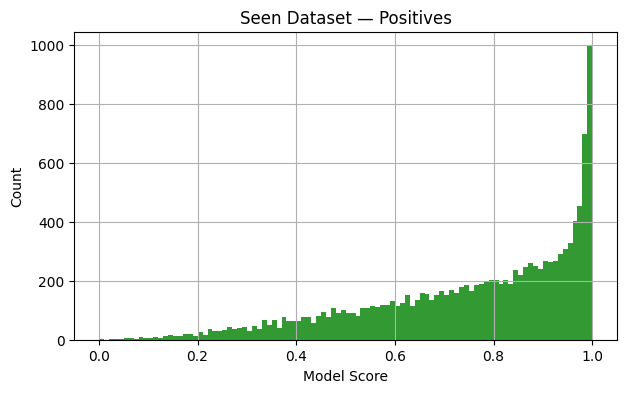

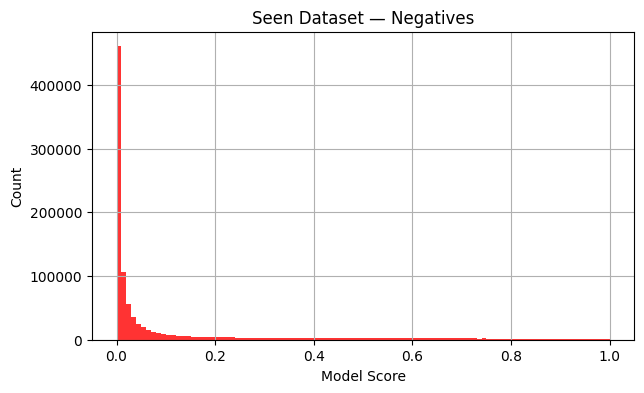

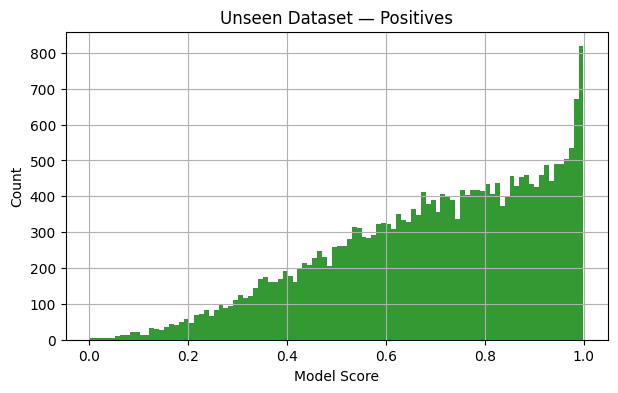

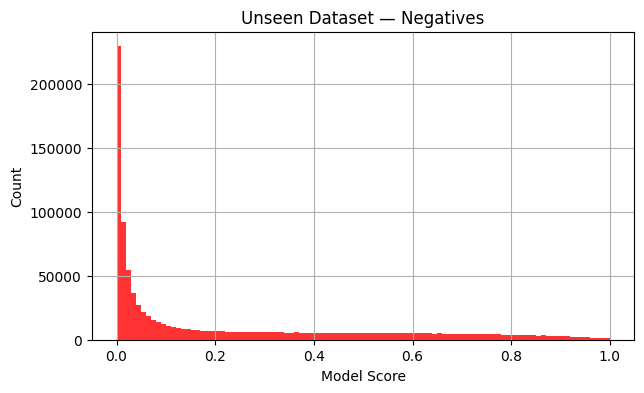

In [72]:
plot_separate_pos_neg(seen_score_label_pairs, "Seen Dataset")
plot_separate_pos_neg(unseen_score_label_pairs, "Unseen Dataset")


In [61]:
seen_dataset.to_pickle('seen_df.pkl')
unseen_dataset.to_pickle('unseen_df.pkl')

In [79]:
(seen_pos/seen_neg)*2, (unseen_pos/unseen_neg)

(0.025533880092445366, 0.025594742391112608)

In [73]:
## baseline pr 

seen_pos = len([i for i in seen_score_label_pairs if i[1] == 1])
seen_neg = len([i for i in seen_score_label_pairs if i[1] == 0])
print(seen_pos/(seen_pos+seen_neg))

unseen_pos = len([i for i in unseen_score_label_pairs if i[1] == 1])
unseen_neg = len([i for i in unseen_score_label_pairs if i[1] == 0])
print(unseen_pos/(unseen_pos+unseen_neg))

0.012606
0.024956


In [50]:
summary_df = pd.DataFrame([seen_metrics, unseen_metrics], index=['Seen', 'Unseen'])

In [51]:
summary_df

,ROC AUC,PR AUC,P@10,P@100,AP@10,AP@100,MRR
Seen,0.896364,0.273084,0.226422,0.067247,0.551153,0.465410,0.611823
Unseen,0.781065,0.187702,0.182773,0.113057,0.505829,0.470097,0.548047


In [32]:
seen_metrics, seen_scores = evaluate_dataset(model, seen_df, 'cuda')
unseen_metrics, unseen_scores = evaluate_dataset(model, unseen_df, 'cuda')
seen_scored_df = pd.DataFrame(seen_scores)
unseen_scored_df = pd.DataFrame(unseen_scores)

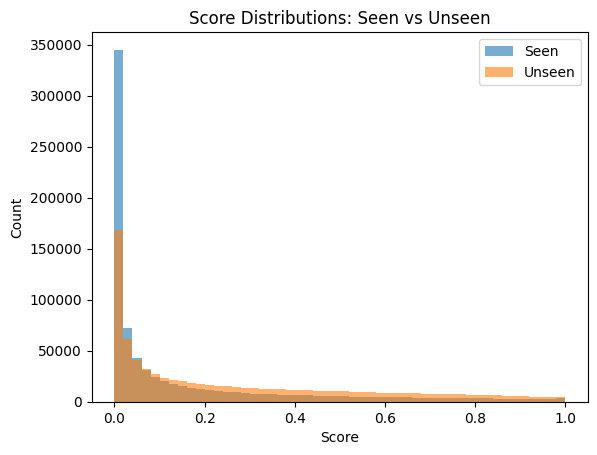

In [34]:
import matplotlib.pyplot as plt

plt.hist(seen_scored_df['score'], bins=50, alpha=0.6, label='Seen')
plt.hist(unseen_scored_df['score'], bins=50, alpha=0.6, label='Unseen')
plt.xlabel('Score')
plt.ylabel('Count')
plt.legend()
plt.title('Score Distributions: Seen vs Unseen')
plt.show()

In [35]:
summary_df = pd.DataFrame([seen_metrics, unseen_metrics], index=['Seen', 'Unseen'])
summary_df

,ROC AUC,PR AUC,P@10,P@100,AP@10,AP@100,MRR
Seen,0.896603,0.270962,0.185305,0.067338,0.565223,0.522252,0.616553
Unseen,0.783248,0.188487,0.184583,0.114661,0.508092,0.472977,0.549936
